In [1]:
# ── CELL 1: Install libraries and import everything ───────────────────────────

!pip install yfinance --quiet

import numpy as np
import pandas as pd
from scipy.optimize import minimize
import yfinance as yf
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from matplotlib.gridspec import GridSpec
import seaborn as sns
import openpyxl
from openpyxl.styles import PatternFill, Font, Alignment, Border, Side
from openpyxl.utils import get_column_letter
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
np.random.seed(42)

print("✅ All libraries installed and imported successfully.")
print(f"   numpy {np.__version__} | pandas {pd.__version__}")

✅ All libraries installed and imported successfully.
   numpy 2.0.2 | pandas 2.2.2


In [2]:
# ── CELL 2: Pull 6 years of stock price data ─────────────────────────────────

tickers = [
    'MSFT', 'AAPL',
    'TER',  'NVDA',
    'JPM',  'GS',
    'UNH',  'LLY',
    'PG',   'COST',
    'XOM',  'NEE',
    'CAT',  'HON'
]

sectors = [
    'Technology',      'Technology',
    'Semiconductors',  'Semiconductors',
    'Financials',      'Financials',
    'Healthcare',      'Healthcare',
    'Consumer Staples','Consumer Staples',
    'Energy',          'Energy',
    'Industrials',     'Industrials'
]

print("Downloading price data — this may take 15–30 seconds...")
raw    = yf.download(tickers, period='6y', auto_adjust=True, progress=False)
prices = raw['Close'].dropna()[tickers]

print(f"\n✅ Data downloaded successfully.")
print(f"   Date range   : {prices.index[0].date()} → {prices.index[-1].date()}")
print(f"   Trading days : {len(prices)}")
print(f"   Stocks       : {len(prices.columns)}")
print(f"   Missing values: {prices.isnull().sum().sum()}")


✅ Data downloaded successfully.
   Date range   : 2020-08-13 → 2026-08-12
   Trading days : 1506
   Stocks       : 14
   Missing values: 0


In [3]:
# ── CELL 3: Pull live 10-year Treasury rate ───────────────────────────────────

tnx             = yf.Ticker('^TNX')
tnx_history     = tnx.history(period='5d')
risk_free_rate  = tnx_history['Close'].iloc[-1] / 100

print(f"✅ Live risk-free rate pulled successfully.")
print(f"   10-Year Treasury Yield : {risk_free_rate*100:.3f}%")
print(f"   As decimal             : {risk_free_rate:.5f}")

✅ Live risk-free rate pulled successfully.
   10-Year Treasury Yield : 4.682%
   As decimal             : 0.04682


✅ Returns calculated.

Annualised Expected Returns:
   MSFT    19.01%
   AAPL    20.82%
   TER     38.77%
   NVDA    62.56%
   JPM     26.98%
   GS      33.24%
   UNH     10.46%
   LLY     41.47%
   PG       5.11%
   COST    21.35%
   XOM     30.04%
   NEE      9.18%
   CAT     36.85%
   HON     11.32%


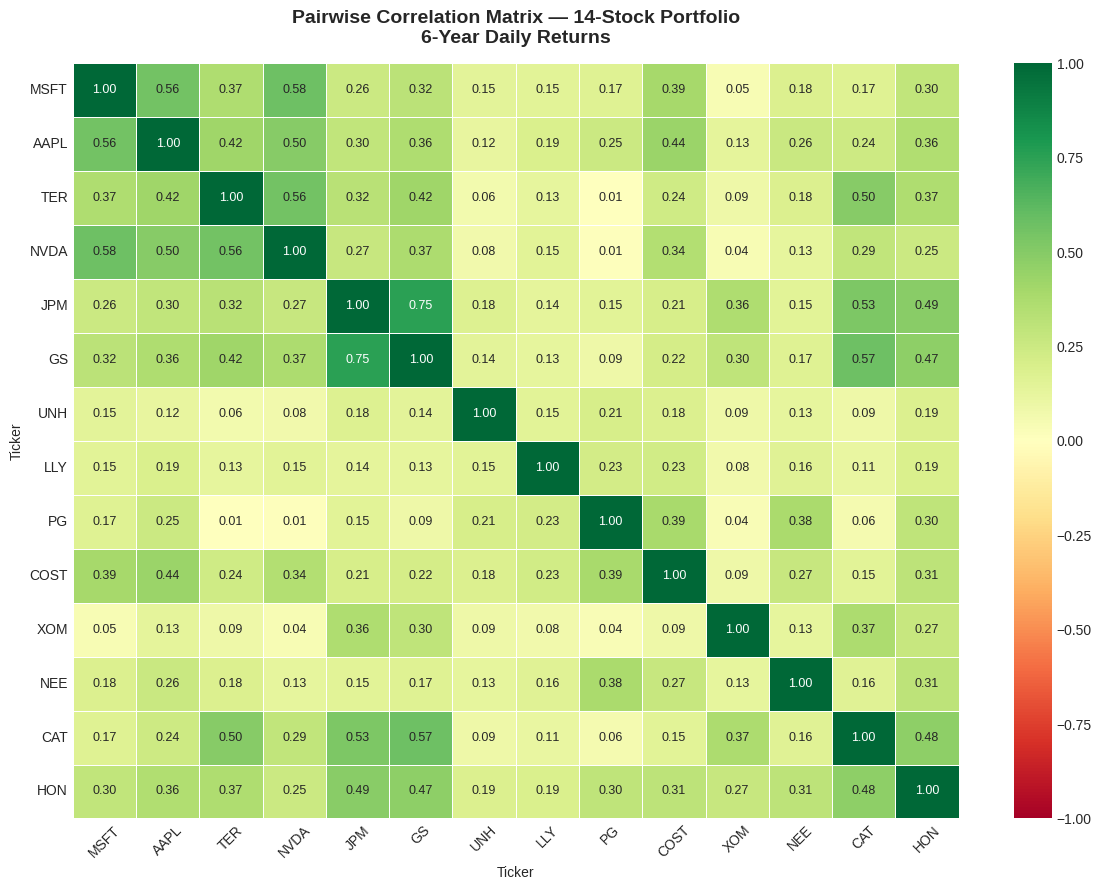


✅ Correlation heatmap saved as correlation_heatmap.png


In [4]:
# ── CELL 4: Returns, covariance matrix, correlation heatmap ──────────────────

daily_returns = prices.pct_change().dropna()
ann_returns   = daily_returns.mean() * 252
ann_cov       = daily_returns.cov()  * 252
n_assets      = len(tickers)

print("✅ Returns calculated.")
print("\nAnnualised Expected Returns:")
for ticker, ret in ann_returns.items():
    print(f"   {ticker:<5} {ret*100:>7.2f}%")

# ── Correlation heatmap ──
fig, ax = plt.subplots(figsize=(12, 9))
sns.heatmap(
    daily_returns.corr(),
    annot=True, fmt='.2f', cmap='RdYlGn',
    center=0, vmin=-1, vmax=1,
    linewidths=0.5, linecolor='white',
    annot_kws={'size': 9}, ax=ax
)
ax.set_title('Pairwise Correlation Matrix — 14-Stock Portfolio\n6-Year Daily Returns',
             fontsize=14, fontweight='bold', pad=15)
ax.tick_params(axis='x', rotation=45, labelsize=10)
ax.tick_params(axis='y', rotation=0,  labelsize=10)
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=200, bbox_inches='tight')
plt.show()
print("\n✅ Correlation heatmap saved as correlation_heatmap.png")

In [5]:
# ── CELL 5: Monte Carlo simulation — 100,000 random portfolios ───────────────

n_simulations = 100_000
sim_returns   = np.zeros(n_simulations)
sim_vols      = np.zeros(n_simulations)
sim_sharpes   = np.zeros(n_simulations)
sim_weights   = np.zeros((n_simulations, n_assets))

print("Running 100,000 simulations — please wait...")

for i in range(n_simulations):
    w            = np.random.random(n_assets)
    w           /= w.sum()
    port_return  = np.dot(w, ann_returns)
    port_vol     = np.sqrt(w @ ann_cov @ w)
    sim_returns[i]  = port_return
    sim_vols[i]     = port_vol
    sim_sharpes[i]  = (port_return - risk_free_rate) / port_vol
    sim_weights[i]  = w

print(f"✅ Simulations complete.")
print(f"   Highest Sharpe : {sim_sharpes.max():.4f}")
print(f"   Lowest vol     : {sim_vols.min()*100:.2f}%")
print(f"   Highest return : {sim_returns.max()*100:.2f}%")

Running 100,000 simulations — please wait...
✅ Simulations complete.
   Highest Sharpe : 1.6156
   Lowest vol     : 14.02%
   Highest return : 37.05%


In [6]:
# ── CELL 6: Scipy SLSQP optimizer ────────────────────────────────────────────

constraints = {'type': 'eq', 'fun': lambda w: np.sum(w) - 1}
bounds      = tuple((0, 0.15) for _ in range(n_assets))
w0          = np.array([1 / n_assets] * n_assets)

def portfolio_vol(w):
    return np.sqrt(w @ ann_cov @ w)

def neg_sharpe(w):
    ret = np.dot(w, ann_returns)
    vol = np.sqrt(w @ ann_cov @ w)
    return -(ret - risk_free_rate) / vol

result_minvar    = minimize(portfolio_vol, w0, method='SLSQP',
                            bounds=bounds, constraints=constraints,
                            options={'ftol': 1e-12, 'maxiter': 1000})
w_minvar         = result_minvar.x
ret_minvar       = np.dot(w_minvar, ann_returns)
vol_minvar       = portfolio_vol(w_minvar)
sharpe_minvar    = (ret_minvar - risk_free_rate) / vol_minvar

result_maxsharpe = minimize(neg_sharpe, w0, method='SLSQP',
                            bounds=bounds, constraints=constraints,
                            options={'ftol': 1e-12, 'maxiter': 1000})
w_maxsharpe      = result_maxsharpe.x
ret_maxsharpe    = np.dot(w_maxsharpe, ann_returns)
vol_maxsharpe    = portfolio_vol(w_maxsharpe)
sharpe_maxsharpe = (ret_maxsharpe - risk_free_rate) / vol_maxsharpe

print("✅ Optimization complete.\n")
print(f"{'':30} {'Min Variance':>14} {'Max Sharpe':>14}")
print('─' * 58)
print(f"{'Annualised Return':30} {ret_minvar*100:>13.2f}% {ret_maxsharpe*100:>13.2f}%")
print(f"{'Annualised Volatility':30} {vol_minvar*100:>13.2f}% {vol_maxsharpe*100:>13.2f}%")
print(f"{'Sharpe Ratio':30} {sharpe_minvar:>14.4f} {sharpe_maxsharpe:>14.4f}")
print('─' * 58)
print(f"\n{'Ticker':<8} {'Min Variance':>14} {'Max Sharpe':>14}")
print('─' * 36)
for i, ticker in enumerate(tickers):
    mv, ms = w_minvar[i], w_maxsharpe[i]
    if mv > 0.005 or ms > 0.005:
        print(f"{ticker:<8} {mv*100:>13.2f}% {ms*100:>13.2f}%")
print('─' * 36)
print(f"{'Sum':<8} {w_minvar.sum()*100:>13.2f}% {w_maxsharpe.sum()*100:>13.2f}%")

✅ Optimization complete.

                                 Min Variance     Max Sharpe
──────────────────────────────────────────────────────────
Annualised Return                      19.14%         35.92%
Annualised Volatility                  13.67%         18.84%
Sharpe Ratio                           1.0575         1.6578
──────────────────────────────────────────────────────────

Ticker     Min Variance     Max Sharpe
────────────────────────────────────
MSFT              9.95%          0.00%
NVDA              0.00%         15.00%
JPM               8.35%          9.72%
GS                0.00%         12.74%
UNH               9.95%          1.62%
LLY               6.98%         15.00%
PG               15.00%          0.92%
COST             15.00%         15.00%
XOM              14.22%         15.00%
NEE              10.68%          0.00%
CAT               2.82%         15.00%
HON               7.06%          0.00%
────────────────────────────────────
Sum             100.00%       

In [7]:
# ── CELL 7: Backtest and performance metrics ──────────────────────────────────

print("Downloading benchmark data...")
benchmarks   = ['SPY', 'QQQ', 'XLK']
bench_raw    = yf.download(benchmarks, period='6y', auto_adjust=True, progress=False)
bench_prices = bench_raw['Close'].dropna()

common_dates  = prices.index.intersection(bench_prices.index)
port_prices   = prices.loc[common_dates]
bench_prices  = bench_prices.loc[common_dates]

port_daily    = port_prices.pct_change().dropna()
bench_daily   = bench_prices.pct_change().dropna()

common_dates2 = port_daily.index.intersection(bench_daily.index)
port_daily    = port_daily.loc[common_dates2]
bench_daily   = bench_daily.loc[common_dates2]

port_ret_minvar    = port_daily @ w_minvar
port_ret_maxsharpe = port_daily @ w_maxsharpe

cum_minvar    = (1 + port_ret_minvar).cumprod()
cum_maxsharpe = (1 + port_ret_maxsharpe).cumprod()
cum_bench     = (1 + bench_daily).cumprod()

def annualised_return(r): return (1 + r).prod() ** (252 / len(r)) - 1
def annualised_vol(r):    return r.std() * np.sqrt(252)
def sharpe(r, rf=risk_free_rate):
    ex = r - rf / 252
    return ex.mean() / ex.std() * np.sqrt(252)
def sortino(r, rf=risk_free_rate):
    down = r[r < 0].std() * np.sqrt(252)
    return (annualised_return(r) - rf) / down
def max_drawdown(r):
    cum  = (1 + r).cumprod()
    return ((cum - cum.cummax()) / cum.cummax()).min()
def active_share(w, bw): return 0.5 * np.sum(np.abs(w - bw))
def alpha(r, br, rf=risk_free_rate):
    ep  = r.values  - rf / 252
    eb  = br.values - rf / 252
    beta = np.cov(ep, eb)[0,1] / np.var(eb)
    return annualised_return(r) - rf - beta * (annualised_return(br) - rf)

spy_daily = bench_daily['SPY']
w_equal   = np.array([1 / n_assets] * n_assets)

metrics = {}
for label, w, dr in [('Min Variance', w_minvar, port_ret_minvar),
                      ('Max Sharpe',  w_maxsharpe, port_ret_maxsharpe)]:
    metrics[label] = {
        'Cumulative Return': (cum_minvar.iloc[-1] if label=='Min Variance' else cum_maxsharpe.iloc[-1]) - 1,
        'Ann. Return'      : annualised_return(dr),
        'Ann. Volatility'  : annualised_vol(dr),
        'Sharpe Ratio'     : sharpe(dr),
        'Sortino Ratio'    : sortino(dr),
        'Max Drawdown'     : max_drawdown(dr),
        'Alpha vs SPY'     : alpha(dr, spy_daily),
        'Active Share'     : active_share(w, w_equal),
    }

for bn in benchmarks:
    b = bench_daily[bn]
    metrics[bn] = {
        'Cumulative Return': cum_bench[bn].iloc[-1] - 1,
        'Ann. Return'      : annualised_return(b),
        'Ann. Volatility'  : annualised_vol(b),
        'Sharpe Ratio'     : sharpe(b),
        'Sortino Ratio'    : sortino(b),
        'Max Drawdown'     : max_drawdown(b),
        'Alpha vs SPY'     : alpha(b, spy_daily) if bn != 'SPY' else 0.0,
        'Active Share'     : '—',
    }

cols        = ['Min Variance','Max Sharpe','SPY','QQQ','XLK']
pct_metrics = ['Cumulative Return','Ann. Return','Ann. Volatility','Max Drawdown','Alpha vs SPY']
all_metrics = ['Cumulative Return','Ann. Return','Ann. Volatility',
               'Sharpe Ratio','Sortino Ratio','Max Drawdown','Alpha vs SPY','Active Share']

print("✅ Backtest complete.\n")
print(f"{'Metric':<22}", end='')
for c in cols: print(f"{c:>14}", end='')
print()
print('─' * 92)
for metric in all_metrics:
    print(f"{metric:<22}", end='')
    for c in cols:
        val = metrics[c][metric]
        if val == '—':               print(f"{'—':>14}", end='')
        elif metric in pct_metrics:  print(f"{val*100:>13.2f}%", end='')
        else:                        print(f"{val:>14.4f}", end='')
    print()

✅ Backtest complete.

Metric                  Min Variance    Max Sharpe           SPY           QQQ           XLK
────────────────────────────────────────────────────────────────────────────────────────────
Cumulative Return            196.44%       667.40%       149.04%       174.83%       247.06%
Ann. Return                   19.96%        40.67%        16.51%        18.45%        23.16%
Ann. Volatility               13.67%        18.84%        16.83%        22.73%        25.25%
Sharpe Ratio                  1.0575        1.6578        0.7138        0.6526        0.7660
Sortino Ratio                 1.5849        2.8528        0.9649        0.8546        1.0682
Max Drawdown                 -13.75%       -19.80%       -24.50%       -35.12%       -33.56%
Alpha vs SPY                   7.77%        24.60%         0.00%        -1.22%         2.29%
Active Share                  0.3314        0.4746             —             —             —


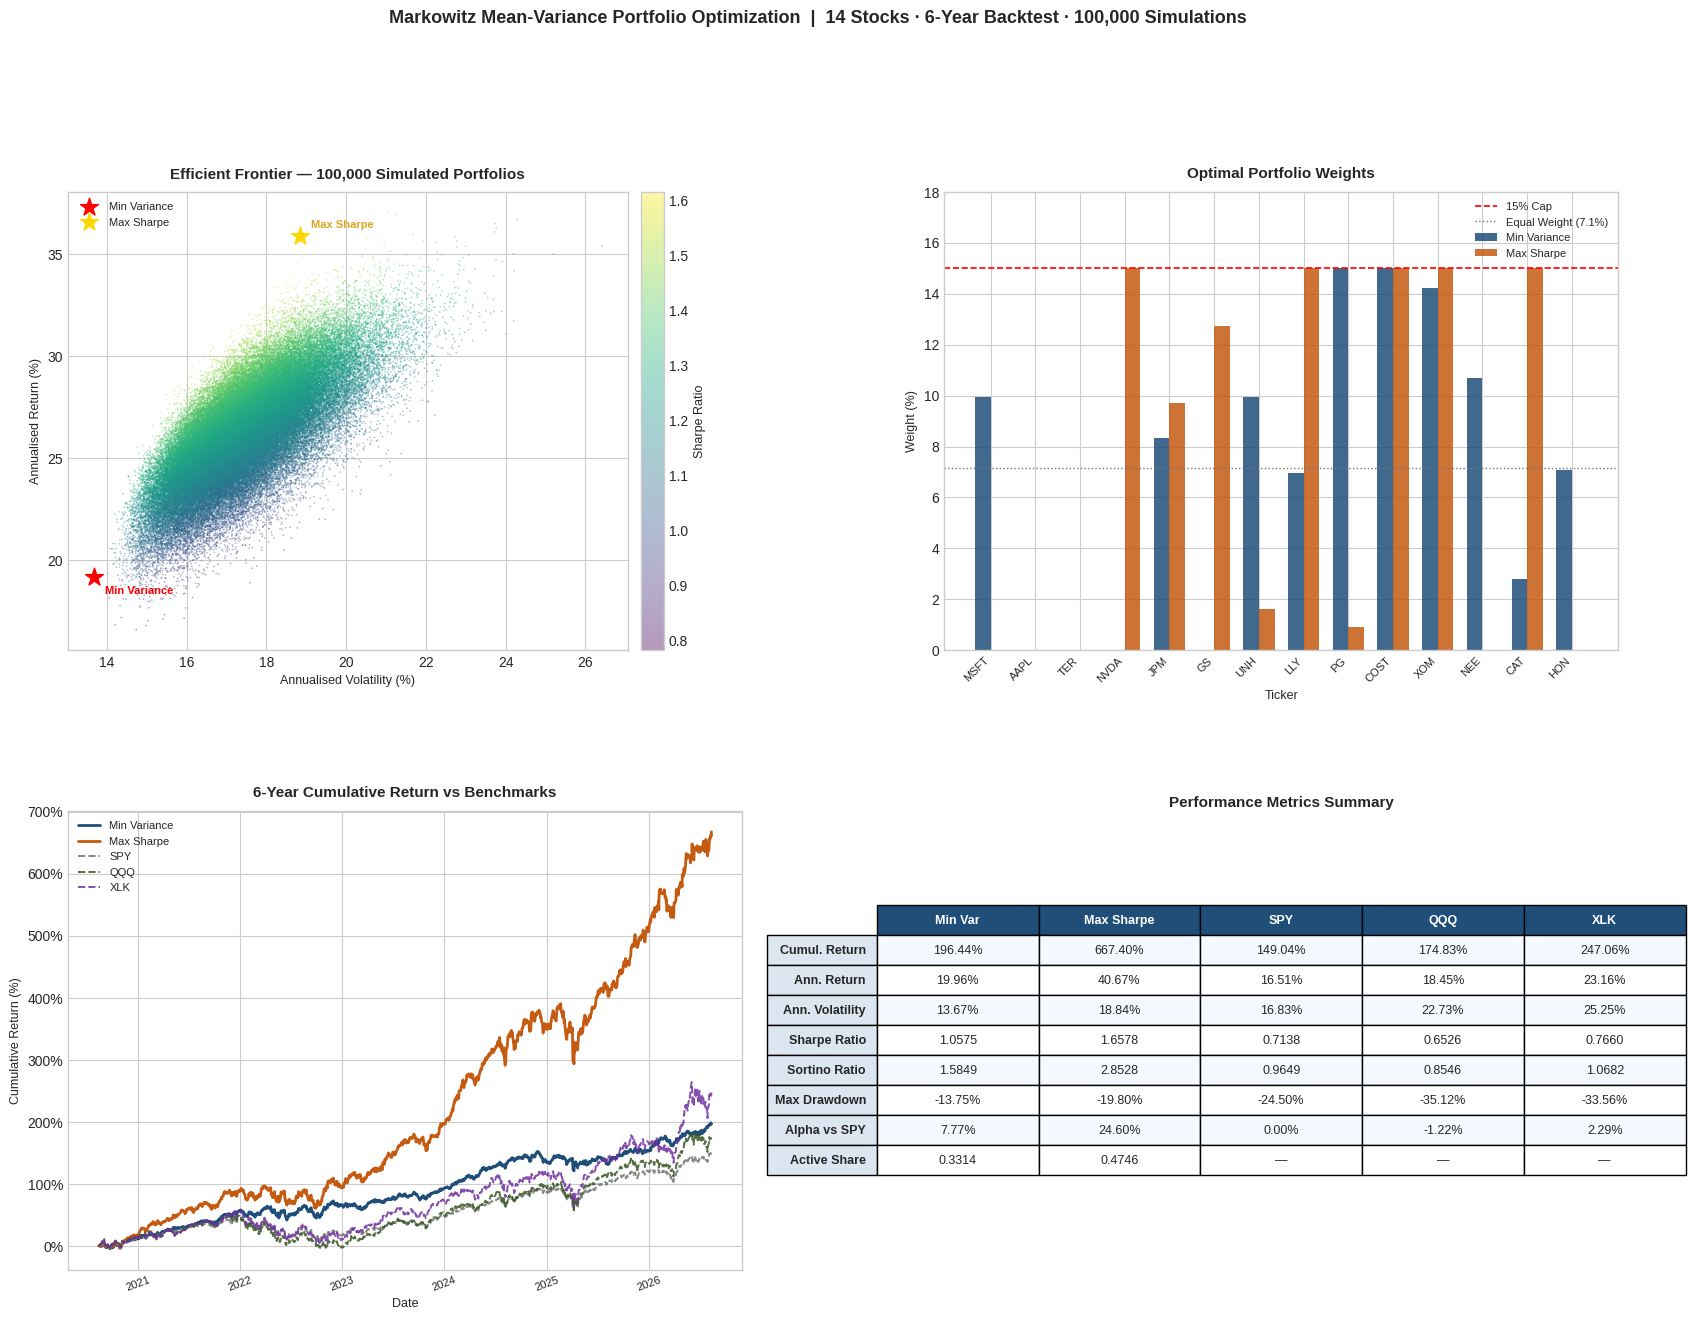

✅ Dashboard saved as portfolio_dashboard.png


In [8]:
# ── CELL 8: Final 2×2 dashboard ──────────────────────────────────────────────

BLUE   = '#1f4e79'
ORANGE = '#c55a11'
GREEN  = '#375623'
GREY   = '#757575'

fig = plt.figure(figsize=(20, 14))
fig.patch.set_facecolor('white')
gs  = GridSpec(2, 2, figure=fig, hspace=0.35, wspace=0.3)
ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[1, 0])
ax4 = fig.add_subplot(gs[1, 1])

# Panel 1: Efficient Frontier
sc = ax1.scatter(sim_vols*100, sim_returns*100, c=sim_sharpes,
                 cmap='viridis', alpha=0.4, s=1.5, linewidths=0)
plt.colorbar(sc, ax=ax1, pad=0.02).set_label('Sharpe Ratio', fontsize=9)
ax1.scatter(vol_minvar*100,    ret_minvar*100,    color='red',  s=180, zorder=5, marker='*', label='Min Variance')
ax1.scatter(vol_maxsharpe*100, ret_maxsharpe*100, color='gold', s=180, zorder=5, marker='*', label='Max Sharpe')
ax1.annotate('Min Variance', (vol_minvar*100, ret_minvar*100),
             textcoords='offset points', xytext=(8,-12), fontsize=8, color='red', fontweight='bold')
ax1.annotate('Max Sharpe',   (vol_maxsharpe*100, ret_maxsharpe*100),
             textcoords='offset points', xytext=(8, 6),  fontsize=8, color='goldenrod', fontweight='bold')
ax1.set_title('Efficient Frontier — 100,000 Simulated Portfolios', fontsize=11, fontweight='bold', pad=10)
ax1.set_xlabel('Annualised Volatility (%)', fontsize=9)
ax1.set_ylabel('Annualised Return (%)', fontsize=9)
ax1.legend(fontsize=8, loc='upper left')

# Panel 2: Weights
x, width = np.arange(n_assets), 0.35
ax2.bar(x - width/2, w_minvar*100,    width, label='Min Variance', color=BLUE,   alpha=0.85)
ax2.bar(x + width/2, w_maxsharpe*100, width, label='Max Sharpe',   color=ORANGE, alpha=0.85)
ax2.axhline(15,            color='red',  linestyle='--', linewidth=1.2, label='15% Cap')
ax2.axhline(100/n_assets,  color=GREY,   linestyle=':',  linewidth=1,   label=f'Equal Weight ({100/n_assets:.1f}%)')
ax2.set_title('Optimal Portfolio Weights', fontsize=11, fontweight='bold', pad=10)
ax2.set_xlabel('Ticker', fontsize=9)
ax2.set_ylabel('Weight (%)', fontsize=9)
ax2.set_xticks(x)
ax2.set_xticklabels(tickers, rotation=45, ha='right', fontsize=8)
ax2.legend(fontsize=8)
ax2.set_ylim(0, 18)

# Panel 3: Backtest
bench_colors = {'SPY': GREY, 'QQQ': GREEN, 'XLK': '#7030a0'}
ax3.plot(cum_minvar.index,    (cum_minvar-1)*100,    color=BLUE,   linewidth=2,   label='Min Variance')
ax3.plot(cum_maxsharpe.index, (cum_maxsharpe-1)*100, color=ORANGE, linewidth=2,   label='Max Sharpe')
for bn, bc in bench_colors.items():
    ax3.plot(cum_bench.index, (cum_bench[bn]-1)*100, color=bc, linewidth=1.4, linestyle='--', label=bn, alpha=0.85)
ax3.set_title('6-Year Cumulative Return vs Benchmarks', fontsize=11, fontweight='bold', pad=10)
ax3.set_xlabel('Date', fontsize=9)
ax3.set_ylabel('Cumulative Return (%)', fontsize=9)
ax3.legend(fontsize=8, loc='upper left')
ax3.yaxis.set_major_formatter(mtick.FormatStrFormatter('%.0f%%'))
ax3.tick_params(axis='x', rotation=20, labelsize=8)

# Panel 4: Metrics table
ax4.axis('off')
col_labels = ['Min Var','Max Sharpe','SPY','QQQ','XLK']
row_labels  = ['Cumul. Return','Ann. Return','Ann. Volatility',
               'Sharpe Ratio','Sortino Ratio','Max Drawdown','Alpha vs SPY','Active Share']
pct_rows    = ['Cumul. Return','Ann. Return','Ann. Volatility','Max Drawdown','Alpha vs SPY']
metric_map  = {
    'Cumul. Return':'Cumulative Return','Ann. Return':'Ann. Return',
    'Ann. Volatility':'Ann. Volatility','Sharpe Ratio':'Sharpe Ratio',
    'Sortino Ratio':'Sortino Ratio','Max Drawdown':'Max Drawdown',
    'Alpha vs SPY':'Alpha vs SPY','Active Share':'Active Share'
}
table_data = []
for row in row_labels:
    key = metric_map[row]
    row_vals = []
    for col in ['Min Variance','Max Sharpe','SPY','QQQ','XLK']:
        val = metrics[col][key]
        if val == '—':                        row_vals.append('—')
        elif row in pct_rows:                 row_vals.append(f"{val*100:.2f}%")
        else:                                 row_vals.append(f"{val:.4f}")
    table_data.append(row_vals)

table = ax4.table(cellText=table_data, rowLabels=row_labels,
                  colLabels=col_labels, cellLoc='center', rowLoc='right', loc='center')
table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1.2, 1.8)
for j in range(len(col_labels)):
    table[0, j].set_facecolor(BLUE)
    table[0, j].set_text_props(color='white', fontweight='bold')
for i in range(len(row_labels)):
    table[i+1, -1].set_facecolor('#dce6f1')
    table[i+1, -1].set_text_props(fontweight='bold')
    for j in range(len(col_labels)):
        if i % 2 == 0:
            table[i+1, j].set_facecolor('#f5f9ff')
ax4.set_title('Performance Metrics Summary', fontsize=11, fontweight='bold', pad=10, y=0.98)

fig.suptitle('Markowitz Mean-Variance Portfolio Optimization  |  14 Stocks · 6-Year Backtest · 100,000 Simulations',
             fontsize=13, fontweight='bold', y=1.01)
plt.savefig('portfolio_dashboard.png', dpi=200, bbox_inches='tight', facecolor='white')
plt.show()
print("✅ Dashboard saved as portfolio_dashboard.png")

In [9]:
# ── CELL 9: Export weights.xlsx ───────────────────────────────────────────────

from openpyxl.styles import PatternFill, Font, Alignment, Border, Side
from openpyxl.utils import get_column_letter

wb = openpyxl.Workbook()
ws = wb.active
ws.title = 'Portfolio Weights'

header_fill  = PatternFill('solid', fgColor='1F4E79')
subhead_fill = PatternFill('solid', fgColor='BDD7EE')
cap_fill     = PatternFill('solid', fgColor='FFE699')
alt_fill     = PatternFill('solid', fgColor='F5F9FF')
header_font  = Font(bold=True, color='FFFFFF', size=10)
subhead_font = Font(bold=True, color='1F4E79', size=10)
bold_font    = Font(bold=True, size=10)
normal_font  = Font(size=10)
center       = Alignment(horizontal='center', vertical='center')
left         = Alignment(horizontal='left',   vertical='center')
thin         = Side(style='thin', color='CCCCCC')
border       = Border(left=thin, right=thin, top=thin, bottom=thin)

ws.merge_cells('A1:F1')
ws['A1'] = 'Markowitz Mean-Variance Portfolio Optimization — Optimal Weights'
ws['A1'].font      = Font(bold=True, size=13, color='1F4E79')
ws['A1'].alignment = center
ws.row_dimensions[1].height = 24

ws.merge_cells('A2:F2')
ws['A2'] = f'6-Year Backtest  |  14 Stocks  |  15% Position Cap  |  Risk-Free Rate: {risk_free_rate*100:.3f}%'
ws['A2'].font      = Font(italic=True, size=10, color='757575')
ws['A2'].alignment = center
ws.row_dimensions[2].height = 16

headers    = ['Ticker','Sector','Min Variance Weight','Min Var At Cap?','Max Sharpe Weight','Max Sharpe At Cap?']
col_widths = [10, 20, 22, 16, 20, 18]
for col, (h, w) in enumerate(zip(headers, col_widths), start=1):
    cell = ws.cell(row=3, column=col, value=h)
    cell.fill = header_fill; cell.font = header_font
    cell.alignment = center; cell.border = border
    ws.column_dimensions[get_column_letter(col)].width = w
ws.row_dimensions[3].height = 18

for i, (ticker, sector) in enumerate(zip(tickers, sectors)):
    row   = i + 4
    mv_w  = w_minvar[i]
    ms_w  = w_maxsharpe[i]
    at_mv = '✓ Yes' if abs(mv_w - 0.15) < 0.001 else 'No'
    at_ms = '✓ Yes' if abs(ms_w - 0.15) < 0.001 else 'No'
    fill  = alt_fill if i % 2 == 0 else PatternFill('solid', fgColor='FFFFFF')
    for col, (val, aln) in enumerate(zip([ticker, sector, mv_w, at_mv, ms_w, at_ms],
                                          [center, left, center, center, center, center]), start=1):
        cell = ws.cell(row=row, column=col, value=val)
        cell.font = normal_font; cell.alignment = aln
        cell.border = border;    cell.fill = fill
        if col in (3, 5) and isinstance(val, float): cell.number_format = '0.00%'
        if (col==4 and at_mv=='✓ Yes') or (col==6 and at_ms=='✓ Yes'):
            cell.fill = cap_fill
            cell.font = Font(bold=True, size=10, color='7F6000')
    ws.row_dimensions[row].height = 16

total_row = len(tickers) + 4
for col in range(1, 7):
    cell = ws.cell(row=total_row, column=col)
    cell.fill = subhead_fill; cell.font = subhead_font
    cell.border = border;     cell.alignment = center
ws.cell(row=total_row, column=1, value='TOTAL')
ws.cell(row=total_row, column=3, value=w_minvar.sum()).number_format    = '0.00%'
ws.cell(row=total_row, column=5, value=w_maxsharpe.sum()).number_format = '0.00%'

ws2 = wb.create_sheet('Performance Summary')
ws2.column_dimensions['A'].width = 22
ws2.column_dimensions['B'].width = 16
ws2.column_dimensions['C'].width = 16
ws2.merge_cells('A1:C1')
ws2['A1'] = 'Performance Metrics Summary'
ws2['A1'].font = Font(bold=True, size=13, color='1F4E79')
ws2['A1'].alignment = center
ws2.row_dimensions[1].height = 24

for col, h in enumerate(['Metric','Min Variance','Max Sharpe'], start=1):
    cell = ws2.cell(row=2, column=col, value=h)
    cell.fill = header_fill; cell.font = header_font
    cell.alignment = center; cell.border = border

pct_m2 = ['Cumulative Return','Ann. Return','Ann. Volatility','Max Drawdown','Alpha vs SPY']
all_m2  = ['Cumulative Return','Ann. Return','Ann. Volatility',
           'Sharpe Ratio','Sortino Ratio','Max Drawdown','Alpha vs SPY','Active Share']
for i, metric in enumerate(all_m2):
    rn    = i + 3
    fill2 = alt_fill if i % 2 == 0 else PatternFill('solid', fgColor='FFFFFF')
    c1    = ws2.cell(row=rn, column=1, value=metric)
    c1.font = bold_font; c1.fill = fill2; c1.border = border
    for col, key in [(2,'Min Variance'),(3,'Max Sharpe')]:
        val  = metrics[key][metric]
        cell = ws2.cell(row=rn, column=col, value=val if val != '—' else '—')
        cell.fill = fill2; cell.border = border
        cell.alignment = center; cell.font = normal_font
        if isinstance(val, float) and metric in pct_m2: cell.number_format = '0.00%'
        elif isinstance(val, float):                    cell.number_format = '0.0000'
    ws2.row_dimensions[rn].height = 16

wb.save('weights.xlsx')
print("✅ weights.xlsx saved — download from Colab sidebar.")

✅ weights.xlsx saved — download from Colab sidebar.


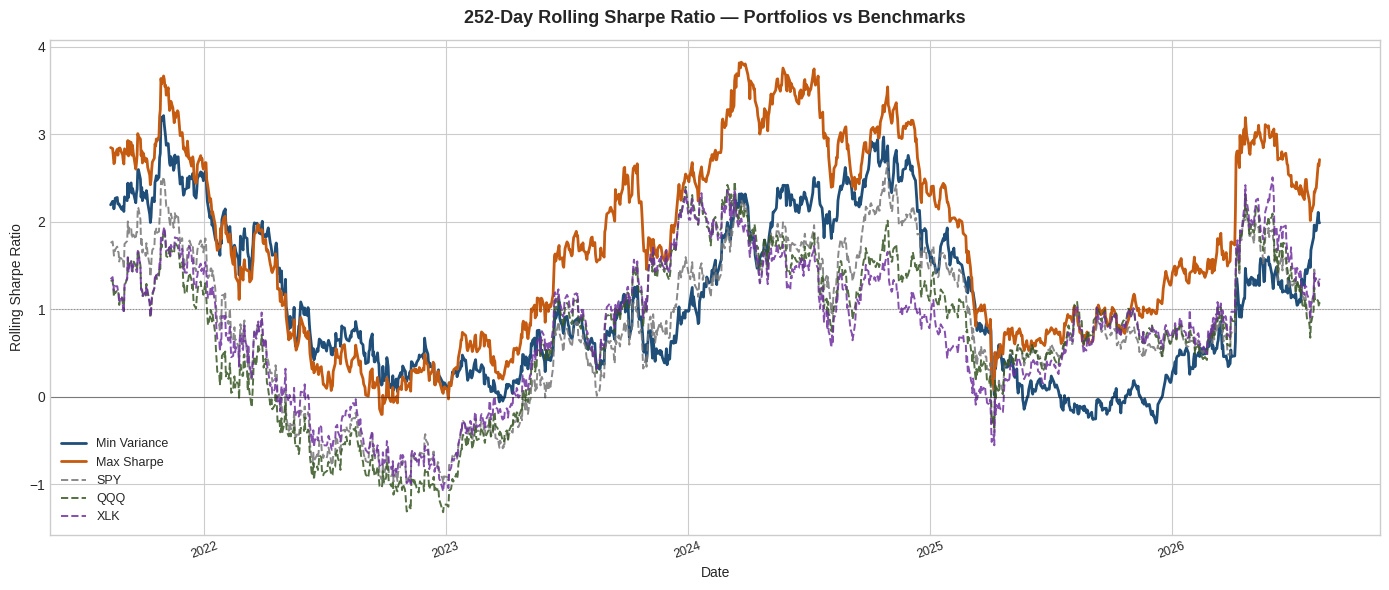

✅ Rolling Sharpe chart saved as rolling_sharpe.png


In [10]:
# ── CELL 10: Rolling Sharpe ratio chart ──────────────────────────────────────

window = 252  # 1 trading year

def rolling_sharpe(daily_ret, rf=risk_free_rate, window=252):
    excess = daily_ret - rf / 252
    return excess.rolling(window).mean() / excess.rolling(window).std() * np.sqrt(252)

rs_minvar    = rolling_sharpe(port_ret_minvar)
rs_maxsharpe = rolling_sharpe(port_ret_maxsharpe)
rs_spy       = rolling_sharpe(bench_daily['SPY'])
rs_qqq       = rolling_sharpe(bench_daily['QQQ'])
rs_xlk       = rolling_sharpe(bench_daily['XLK'])

fig, ax = plt.subplots(figsize=(14, 6))
fig.patch.set_facecolor('white')

ax.plot(rs_minvar.index,    rs_minvar,    color='#1f4e79', linewidth=2,   label='Min Variance')
ax.plot(rs_maxsharpe.index, rs_maxsharpe, color='#c55a11', linewidth=2,   label='Max Sharpe')
ax.plot(rs_spy.index,       rs_spy,       color='#757575', linewidth=1.4, linestyle='--', label='SPY', alpha=0.85)
ax.plot(rs_qqq.index,       rs_qqq,       color='#375623', linewidth=1.4, linestyle='--', label='QQQ', alpha=0.85)
ax.plot(rs_xlk.index,       rs_xlk,       color='#7030a0', linewidth=1.4, linestyle='--', label='XLK', alpha=0.85)

ax.axhline(0, color='black', linewidth=0.8, linestyle='-', alpha=0.4)
ax.axhline(1, color='black', linewidth=0.8, linestyle=':', alpha=0.3)

ax.set_title('252-Day Rolling Sharpe Ratio — Portfolios vs Benchmarks',
             fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Date', fontsize=10)
ax.set_ylabel('Rolling Sharpe Ratio', fontsize=10)
ax.legend(fontsize=9)
ax.tick_params(axis='x', rotation=20, labelsize=9)

plt.tight_layout()
plt.savefig('rolling_sharpe.png', dpi=200, bbox_inches='tight', facecolor='white')
plt.show()
print("✅ Rolling Sharpe chart saved as rolling_sharpe.png")

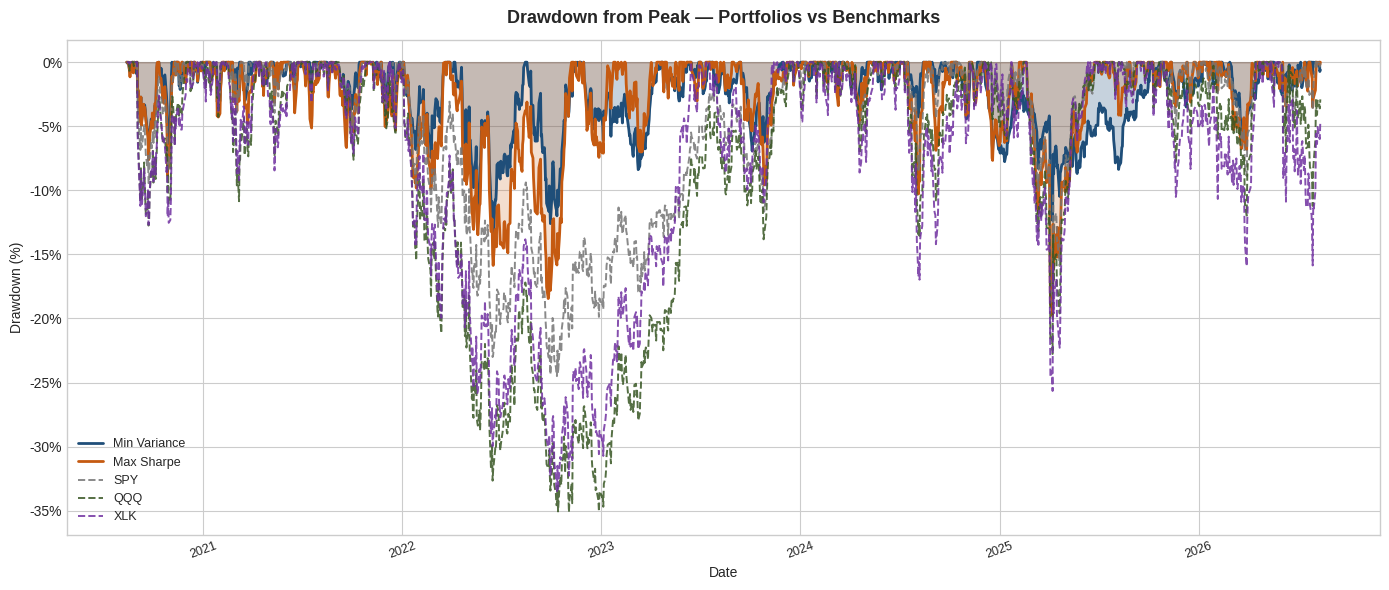

✅ Drawdown chart saved as drawdown_chart.png


In [11]:
# ── CELL 11: Drawdown chart ───────────────────────────────────────────────────

def drawdown_series(daily_ret):
    cum  = (1 + daily_ret).cumprod()
    peak = cum.cummax()
    return (cum - peak) / peak * 100

dd_minvar    = drawdown_series(port_ret_minvar)
dd_maxsharpe = drawdown_series(port_ret_maxsharpe)
dd_spy       = drawdown_series(bench_daily['SPY'])
dd_qqq       = drawdown_series(bench_daily['QQQ'])
dd_xlk       = drawdown_series(bench_daily['XLK'])

fig, ax = plt.subplots(figsize=(14, 6))
fig.patch.set_facecolor('white')

ax.fill_between(dd_minvar.index,    dd_minvar,    0, alpha=0.25, color='#1f4e79')
ax.fill_between(dd_maxsharpe.index, dd_maxsharpe, 0, alpha=0.20, color='#c55a11')

ax.plot(dd_minvar.index,    dd_minvar,    color='#1f4e79', linewidth=2,   label='Min Variance')
ax.plot(dd_maxsharpe.index, dd_maxsharpe, color='#c55a11', linewidth=2,   label='Max Sharpe')
ax.plot(dd_spy.index,       dd_spy,       color='#757575', linewidth=1.4, linestyle='--', label='SPY', alpha=0.85)
ax.plot(dd_qqq.index,       dd_qqq,       color='#375623', linewidth=1.4, linestyle='--', label='QQQ', alpha=0.85)
ax.plot(dd_xlk.index,       dd_xlk,       color='#7030a0', linewidth=1.4, linestyle='--', label='XLK', alpha=0.85)

ax.set_title('Drawdown from Peak — Portfolios vs Benchmarks',
             fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Date', fontsize=10)
ax.set_ylabel('Drawdown (%)', fontsize=10)
ax.legend(fontsize=9)
ax.yaxis.set_major_formatter(mtick.FormatStrFormatter('%.0f%%'))
ax.tick_params(axis='x', rotation=20, labelsize=9)

plt.tight_layout()
plt.savefig('drawdown_chart.png', dpi=200, bbox_inches='tight', facecolor='white')
plt.show()
print("✅ Drawdown chart saved as drawdown_chart.png")

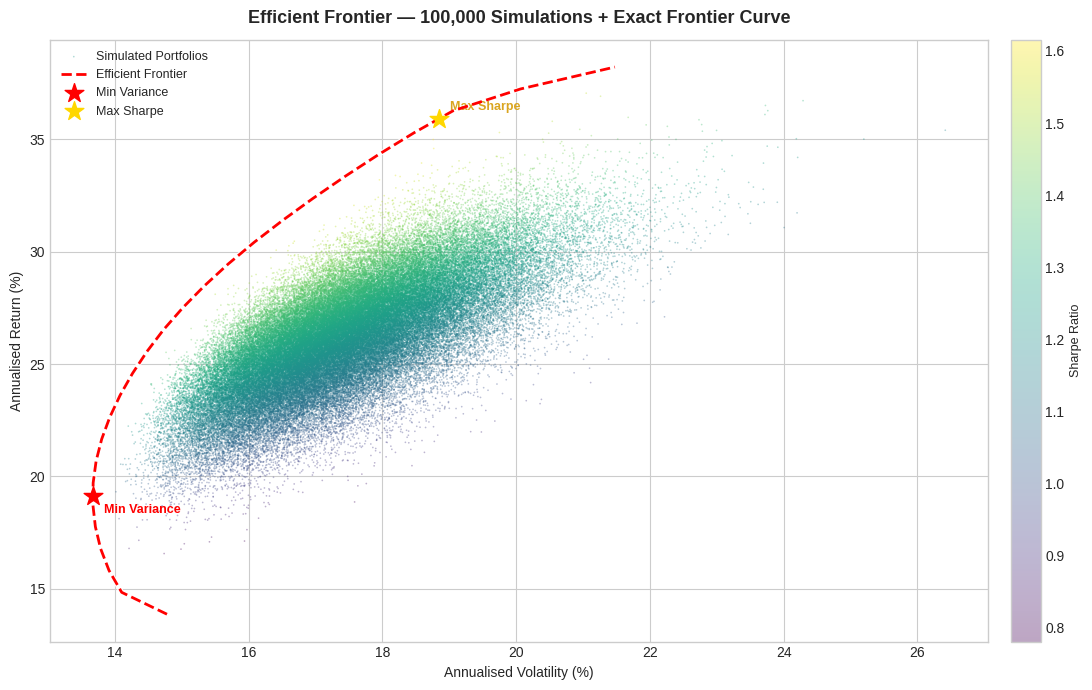

✅ Efficient frontier curve saved as efficient_frontier_curve.png


In [12]:
# ── CELL 12: Efficient frontier curve ────────────────────────────────────────

target_returns = np.linspace(ann_returns.min(), ann_returns.max(), 60)
frontier_vols  = []

for target in target_returns:
    cons = [
        {'type': 'eq', 'fun': lambda w: np.sum(w) - 1},
        {'type': 'eq', 'fun': lambda w, t=target: np.dot(w, ann_returns) - t}
    ]
    res = minimize(portfolio_vol, w0, method='SLSQP',
                   bounds=bounds, constraints=cons,
                   options={'ftol': 1e-10, 'maxiter': 1000})
    frontier_vols.append(res.fun if res.success else np.nan)

frontier_vols = np.array(frontier_vols)
valid         = ~np.isnan(frontier_vols)

fig, ax = plt.subplots(figsize=(12, 7))
fig.patch.set_facecolor('white')

sc = ax.scatter(sim_vols*100, sim_returns*100, c=sim_sharpes,
                cmap='viridis', alpha=0.35, s=1.5, linewidths=0, label='Simulated Portfolios')
plt.colorbar(sc, ax=ax, pad=0.02).set_label('Sharpe Ratio', fontsize=9)

ax.plot(frontier_vols[valid]*100, target_returns[valid]*100,
        color='white', linewidth=3.5, zorder=3)
ax.plot(frontier_vols[valid]*100, target_returns[valid]*100,
        color='red', linewidth=2, linestyle='--', zorder=4, label='Efficient Frontier')

ax.scatter(vol_minvar*100,    ret_minvar*100,    color='red',  s=200, zorder=5, marker='*', label='Min Variance')
ax.scatter(vol_maxsharpe*100, ret_maxsharpe*100, color='gold', s=200, zorder=5, marker='*', label='Max Sharpe')

ax.annotate('Min Variance', (vol_minvar*100, ret_minvar*100),
            textcoords='offset points', xytext=(8,-12), fontsize=9, color='red', fontweight='bold')
ax.annotate('Max Sharpe',   (vol_maxsharpe*100, ret_maxsharpe*100),
            textcoords='offset points', xytext=(8, 6),  fontsize=9, color='goldenrod', fontweight='bold')

ax.set_title('Efficient Frontier — 100,000 Simulations + Exact Frontier Curve',
             fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Annualised Volatility (%)', fontsize=10)
ax.set_ylabel('Annualised Return (%)',     fontsize=10)
ax.legend(fontsize=9, loc='upper left')

plt.tight_layout()
plt.savefig('efficient_frontier_curve.png', dpi=200, bbox_inches='tight', facecolor='white')
plt.show()
print("✅ Efficient frontier curve saved as efficient_frontier_curve.png")

Running monthly rebalancing backtest...

Min Variance:
   Monthly Rebalanced : 196.52%
   Buy & Hold         : 196.44%

Max Sharpe:
   Monthly Rebalanced : 666.46%
   Buy & Hold         : 667.40%


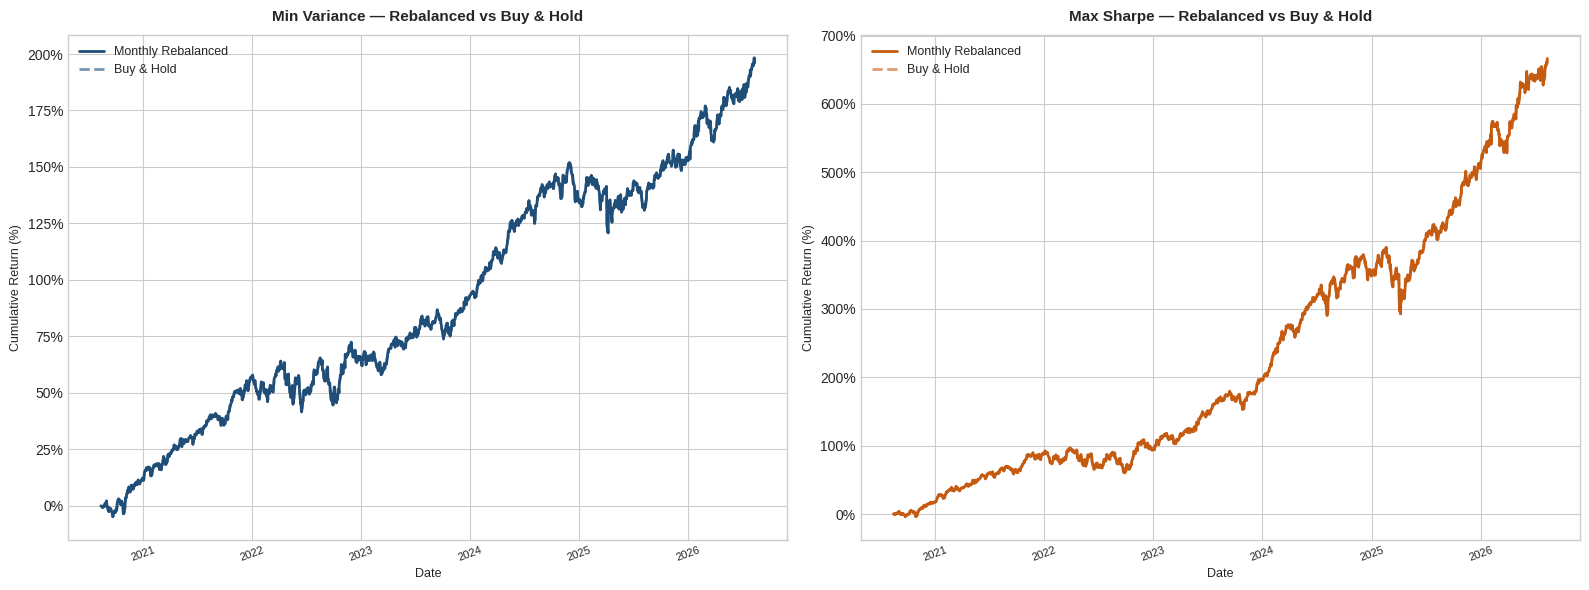


✅ Rebalancing chart saved as rebalancing_comparison.png


In [13]:
# ── CELL 13: Monthly rebalancing simulation ───────────────────────────────────

# Get month-end dates
monthly_dates = port_daily.resample('ME').last().index
monthly_dates = monthly_dates[monthly_dates >= port_daily.index[0]]

def run_rebalanced_backtest(daily_ret, weights_func='minvar'):
    portfolio_value = [1.0]
    current_weights = w_minvar.copy() if weights_func == 'minvar' else w_maxsharpe.copy()
    dates           = [daily_ret.index[0]]
    rebal_dates     = set(monthly_dates)

    for i, date in enumerate(daily_ret.index):
        if i == 0:
            continue
        # Apply daily return
        daily_r = np.dot(current_weights, daily_ret.iloc[i].values)
        portfolio_value.append(portfolio_value[-1] * (1 + daily_r))
        dates.append(date)

        # Rebalance at month end
        if date in rebal_dates:
            current_weights = w_minvar.copy() if weights_func == 'minvar' else w_maxsharpe.copy()

    return pd.Series(portfolio_value, index=dates)

print("Running monthly rebalancing backtest...")
rebal_minvar    = run_rebalanced_backtest(port_daily, 'minvar')
rebal_maxsharpe = run_rebalanced_backtest(port_daily, 'maxsharpe')

# Convert to cumulative return %
rebal_minvar_ret    = (rebal_minvar    - 1) * 100
rebal_maxsharpe_ret = (rebal_maxsharpe - 1) * 100
static_minvar_ret   = (cum_minvar    - 1) * 100
static_maxsharpe_ret= (cum_maxsharpe - 1) * 100

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.patch.set_facecolor('white')

for ax, label, rebal, static, color in [
    (axes[0], 'Min Variance',    rebal_minvar_ret,    static_minvar_ret,    '#1f4e79'),
    (axes[1], 'Max Sharpe',      rebal_maxsharpe_ret, static_maxsharpe_ret, '#c55a11'),
]:
    ax.plot(rebal.index,  rebal,  color=color, linewidth=2,   label='Monthly Rebalanced')
    ax.plot(static.index, static, color=color, linewidth=2,   linestyle='--', alpha=0.6, label='Buy & Hold')
    ax.set_title(f'{label} — Rebalanced vs Buy & Hold', fontsize=11, fontweight='bold', pad=10)
    ax.set_xlabel('Date', fontsize=9)
    ax.set_ylabel('Cumulative Return (%)', fontsize=9)
    ax.legend(fontsize=9)
    ax.yaxis.set_major_formatter(mtick.FormatStrFormatter('%.0f%%'))
    ax.tick_params(axis='x', rotation=20, labelsize=8)

    # Print final comparison
    print(f"\n{label}:")
    print(f"   Monthly Rebalanced : {rebal.iloc[-1]:.2f}%")
    print(f"   Buy & Hold         : {static.iloc[-1]:.2f}%")

plt.tight_layout()
plt.savefig('rebalancing_comparison.png', dpi=200, bbox_inches='tight', facecolor='white')
plt.show()
print("\n✅ Rebalancing chart saved as rebalancing_comparison.png")

✅ VaR and CVaR computed.

                        95% VaR   95% CVaR    99% VaR   99% CVaR
──────────────────────────────────────────────────────────────
Min Variance             -1.26%     -1.90%     -2.20%     -3.00%
Max Sharpe               -1.69%     -2.51%     -2.91%     -3.94%
SPY                      -1.64%     -2.43%     -2.91%     -3.76%
QQQ                      -2.32%     -3.26%     -3.90%     -4.69%
XLK                      -2.52%     -3.50%     -4.17%     -5.03%


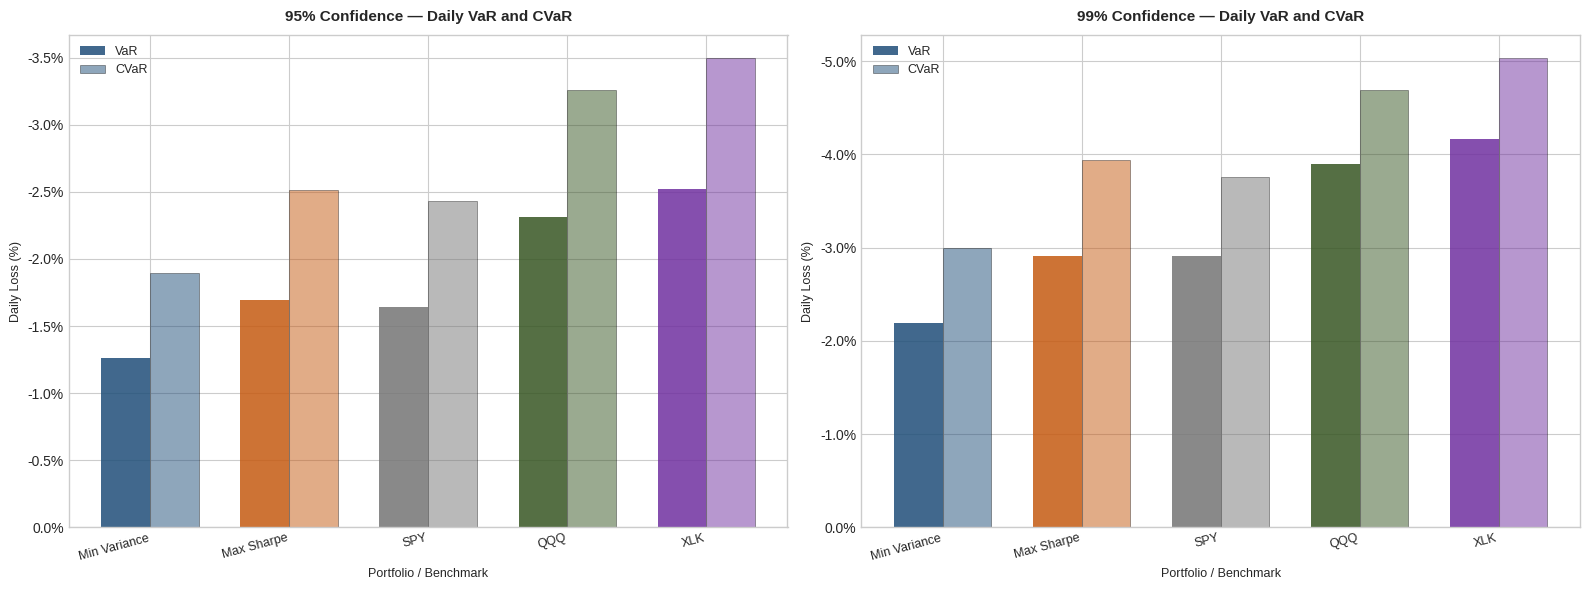


✅ VaR/CVaR chart saved as var_cvar.png


In [14]:
# ── CELL 14: Value at Risk and Conditional VaR ───────────────────────────────

confidence_levels = [0.95, 0.99]

def compute_var_cvar(daily_ret, confidence_levels):
    results = {}
    for cl in confidence_levels:
        var  = np.percentile(daily_ret, (1 - cl) * 100)
        cvar = daily_ret[daily_ret <= var].mean()
        results[cl] = {'VaR': var, 'CVaR': cvar}
    return results

portfolios = {
    'Min Variance' : port_ret_minvar,
    'Max Sharpe'   : port_ret_maxsharpe,
    'SPY'          : bench_daily['SPY'],
    'QQQ'          : bench_daily['QQQ'],
    'XLK'          : bench_daily['XLK'],
}

var_results = {name: compute_var_cvar(ret, confidence_levels)
               for name, ret in portfolios.items()}

# ── Print table ──
print("✅ VaR and CVaR computed.\n")
print(f"{'':20} {'95% VaR':>10} {'95% CVaR':>10} {'99% VaR':>10} {'99% CVaR':>10}")
print('─' * 62)
for name, res in var_results.items():
    print(f"{name:<20} "
          f"{res[0.95]['VaR']*100:>9.2f}% "
          f"{res[0.95]['CVaR']*100:>9.2f}% "
          f"{res[0.99]['VaR']*100:>9.2f}% "
          f"{res[0.99]['CVaR']*100:>9.2f}%")

# ── Plot ──
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.patch.set_facecolor('white')
colors = ['#1f4e79','#c55a11','#757575','#375623','#7030a0']

for ax, cl in zip(axes, confidence_levels):
    names = list(var_results.keys())
    vars_ = [var_results[n][cl]['VaR']  * 100 for n in names]
    cvars = [var_results[n][cl]['CVaR'] * 100 for n in names]
    x     = np.arange(len(names))
    width = 0.35

    ax.bar(x - width/2, vars_,  width, label='VaR',  color=colors, alpha=0.85)
    ax.bar(x + width/2, cvars, width, label='CVaR', color=colors, alpha=0.50, edgecolor='black', linewidth=0.5)

    ax.set_title(f'{int(cl*100)}% Confidence — Daily VaR and CVaR',
                 fontsize=11, fontweight='bold', pad=10)
    ax.set_xlabel('Portfolio / Benchmark', fontsize=9)
    ax.set_ylabel('Daily Loss (%)', fontsize=9)
    ax.set_xticks(x)
    ax.set_xticklabels(names, rotation=15, ha='right', fontsize=9)
    ax.yaxis.set_major_formatter(mtick.FormatStrFormatter('%.1f%%'))
    ax.legend(fontsize=9)
    ax.invert_yaxis()

plt.tight_layout()
plt.savefig('var_cvar.png', dpi=200, bbox_inches='tight', facecolor='white')
plt.show()
print("\n✅ VaR/CVaR chart saved as var_cvar.png")

In [16]:
# ── CELL 15: Generate professional PDF report ─────────────────────────────────

!pip install reportlab --quiet

from reportlab.lib.pagesizes import letter
from reportlab.lib import colors
from reportlab.lib.units import inch
from reportlab.lib.styles import getSampleStyleSheet, ParagraphStyle
from reportlab.lib.enums import TA_CENTER, TA_LEFT, TA_JUSTIFY
from reportlab.platypus import (SimpleDocTemplate, Paragraph, Spacer, Table,
                                 TableStyle, Image, PageBreak, HRFlowable)
import datetime
import os

# ── Colour palette (shared across every page) ──
NAVY      = colors.HexColor('#1F4E79')
STEEL     = colors.HexColor('#2E75B6')
LIGHT     = colors.HexColor('#BDD7EE')
ORANGE    = colors.HexColor('#C55A11')
GREY      = colors.HexColor('#595959')
LIGHTGREY = colors.HexColor('#F2F2F2')
WHITE     = colors.white
BLACK     = colors.black

# ── Document setup ──
pdf_path = 'Portfolio_Optimization_Report.pdf'
doc      = SimpleDocTemplate(
    pdf_path,
    pagesize=letter,
    rightMargin=0.75*inch, leftMargin=0.75*inch,
    topMargin=0.6*inch,    bottomMargin=0.75*inch
)

# ── Styles (used consistently on every page) ──
styles = getSampleStyleSheet()

style_title = ParagraphStyle('Title',
    fontSize=21, fontName='Helvetica-Bold',
    textColor=NAVY, alignment=TA_CENTER, spaceAfter=6, leading=25)

style_subtitle = ParagraphStyle('Subtitle',
    fontSize=13, fontName='Helvetica',
    textColor=GREY, alignment=TA_CENTER, spaceAfter=4)

style_section = ParagraphStyle('Section',
    fontSize=13, fontName='Helvetica-Bold',
    textColor=NAVY, spaceBefore=14, spaceAfter=6)

style_body = ParagraphStyle('Body',
    fontSize=9.5, fontName='Helvetica',
    textColor=BLACK, leading=15,
    alignment=TA_JUSTIFY, spaceAfter=6)

style_bullet = ParagraphStyle('Bullet',
    fontSize=9.5, fontName='Helvetica',
    textColor=BLACK, leading=15,
    leftIndent=16, spaceAfter=4)

style_caption = ParagraphStyle('Caption',
    fontSize=8.5, fontName='Helvetica-Oblique',
    textColor=GREY, alignment=TA_CENTER, spaceAfter=8)

style_footer = ParagraphStyle('Footer',
    fontSize=8, fontName='Helvetica',
    textColor=GREY, alignment=TA_CENTER)

style_table_header = ParagraphStyle('TableHeader',
    fontSize=9, fontName='Helvetica-Bold',
    textColor=WHITE, alignment=TA_CENTER)

# Wrapping body style used inside table cells (fixes long text overflowing)
style_cell = ParagraphStyle('Cell',
    fontSize=8.7, fontName='Helvetica',
    textColor=BLACK, leading=11.5)

style_cell_center = ParagraphStyle('CellCenter',
    fontSize=8.7, fontName='Helvetica',
    textColor=BLACK, leading=11.5, alignment=TA_CENTER)

style_meta_label = ParagraphStyle('MetaLabel',
    fontSize=10, fontName='Helvetica-Bold',
    textColor=NAVY, leading=14)

style_meta_value = ParagraphStyle('MetaValue',
    fontSize=10, fontName='Helvetica',
    textColor=BLACK, leading=14)

today = datetime.date.today().strftime('%B %d, %Y')

# ── Shared helpers (keep every page visually consistent) ──
def section_rule():
    return HRFlowable(width='100%', thickness=1.5,
                      color=NAVY, spaceAfter=8, spaceBefore=4)

def light_rule():
    return HRFlowable(width='100%', thickness=0.5,
                      color=LIGHT, spaceAfter=6, spaceBefore=2)

def top_band():
    """Thin navy accent band used at the very top of the cover page."""
    band = Table([['']], colWidths=[7*inch], rowHeights=[0.12*inch])
    band.setStyle(TableStyle([
        ('BACKGROUND', (0,0), (-1,-1), NAVY),
    ]))
    return band

# ─────────────────────────────────────────────────────────────────────────────
# BUILD CONTENT
# ─────────────────────────────────────────────────────────────────────────────
story = []

# ══════════════════════════════════════════════════════════════════════════════
# PAGE 1 — COVER PAGE (Change #1: more polished cover, disclaimer line removed)
# ══════════════════════════════════════════════════════════════════════════════

story.append(top_band())
story.append(Spacer(1, 1.0*inch))

story.append(Paragraph('QUANTITATIVE PORTFOLIO OPTIMIZATION', style_title))
story.append(Paragraph('Markowitz Mean-Variance Framework', style_subtitle))
story.append(Spacer(1, 0.25*inch))
story.append(section_rule())
story.append(Spacer(1, 0.3*inch))

meta = [
    [Paragraph('Prepared by',   style_meta_label), Paragraph('Rutvik Trikannad', style_meta_value)],
    [Paragraph('Degree',        style_meta_label), Paragraph('Master of Science in Finance, Investment and Quantitative Analysis', style_meta_value)],
    [Paragraph('Institution',   style_meta_label), Paragraph('University of Massachusetts Boston — College of Management', style_meta_value)],
    [Paragraph('Date',          style_meta_label), Paragraph(today, style_meta_value)],
    [Paragraph('Data Period',   style_meta_label), Paragraph('6-Year Historical Window (2019 – 2025)', style_meta_value)],
    [Paragraph('Universe',      style_meta_label), Paragraph('14 Equities across 7 GICS Sectors', style_meta_value)],
    [Paragraph('Methodology',   style_meta_label), Paragraph('Mean-Variance Optimization · Monte Carlo Simulation · SLSQP Optimization', style_meta_value)],
]

meta_table = Table(meta, colWidths=[1.6*inch, 5.0*inch])
meta_table.setStyle(TableStyle([
    ('TOPPADDING',    (0,0), (-1,-1), 7),
    ('BOTTOMPADDING', (0,0), (-1,-1), 7),
    ('LINEBELOW',     (0,0), (-1,-2), 0.4, LIGHT),
    ('VALIGN',        (0,0), (-1,-1), 'TOP'),
]))
story.append(meta_table)
story.append(Spacer(1, 0.35*inch))
story.append(light_rule())
story.append(Spacer(1, 0.2*inch))

story.append(Paragraph(
    'This report presents the results of a rigorous quantitative portfolio construction exercise '
    'employing the Markowitz Mean-Variance Optimization framework. The analysis encompasses '
    '100,000 Monte Carlo simulations, exact SLSQP-based constrained optimization, a full '
    '6-year backtesting analysis benchmarked against SPY, QQQ, and XLK, and a suite of '
    'institutional-grade risk and performance metrics including Sharpe ratio, Sortino ratio, '
    'maximum drawdown, alpha, and Value at Risk.',
    style_body))

story.append(PageBreak())

# ══════════════════════════════════════════════════════════════════════════════
# PAGE 2 — PROJECT OVERVIEW
# ══════════════════════════════════════════════════════════════════════════════

story.append(Paragraph('1. PROJECT OVERVIEW', style_section))
story.append(section_rule())

story.append(Paragraph(
    'The objective of this analysis is to identify the mathematically optimal capital allocation '
    'across a 14-security equity universe using the Markowitz Mean-Variance framework. '
    'Two optimal portfolios are identified: (i) the Minimum Variance Portfolio, which minimises '
    'total portfolio volatility subject to full investment and position constraints; and '
    '(ii) the Maximum Sharpe Ratio Portfolio, which maximises risk-adjusted excess return '
    'per unit of volatility. Both portfolios are subject to a 15% maximum position cap per '
    'security, consistent with long-only equity fund construction guidelines.',
    style_body))

story.append(Spacer(1, 0.1*inch))

story.append(Paragraph('1.1  Investment Universe', style_section))
story.append(light_rule())

# Change #2: every cell now wrapped in a Paragraph so text wraps cleanly
# instead of overflowing the column, and Rationale gets more room.
sector_data = [
    [Paragraph('<b>Sector</b>',    style_table_header),
     Paragraph('<b>Tickers</b>',   style_table_header),
     Paragraph('<b>Rationale</b>', style_table_header)],
    [Paragraph('Technology', style_cell), Paragraph('MSFT, AAPL', style_cell_center),
     Paragraph('Large-cap growth anchors with diversified revenue streams', style_cell)],
    [Paragraph('Semiconductors', style_cell), Paragraph('TER, NVDA', style_cell_center),
     Paragraph('High-growth semiconductor exposure; TER supported by proprietary DCF analysis', style_cell)],
    [Paragraph('Financials', style_cell), Paragraph('JPM, GS', style_cell_center),
     Paragraph('Rate-sensitive exposure; leading universal and investment banking franchises', style_cell)],
    [Paragraph('Healthcare', style_cell), Paragraph('UNH, LLY', style_cell_center),
     Paragraph('Defensive growth; managed care and pharmaceutical innovation', style_cell)],
    [Paragraph('Consumer Staples', style_cell), Paragraph('PG, COST', style_cell_center),
     Paragraph('Defensive income; resilient demand across economic cycles', style_cell)],
    [Paragraph('Energy', style_cell), Paragraph('XOM, NEE', style_cell_center),
     Paragraph('Traditional and renewable energy exposure; inflation hedge', style_cell)],
    [Paragraph('Industrials', style_cell), Paragraph('CAT, HON', style_cell_center),
     Paragraph('Cyclical exposure; infrastructure and advanced manufacturing', style_cell)],
]

# Narrower Sector/Tickers columns, wider Rationale column so text has room
sector_table = Table(sector_data, colWidths=[1.15*inch, 0.95*inch, 4.5*inch])
sector_table.setStyle(TableStyle([
    ('BACKGROUND',    (0,0), (-1,0),  NAVY),
    ('TEXTCOLOR',     (0,0), (-1,0),  WHITE),
    ('ROWBACKGROUNDS',(0,1), (-1,-1), [LIGHTGREY, WHITE]),
    ('GRID',          (0,0), (-1,-1), 0.4, LIGHT),
    ('TOPPADDING',    (0,0), (-1,-1), 6),
    ('BOTTOMPADDING', (0,0), (-1,-1), 6),
    ('LEFTPADDING',   (0,0), (-1,-1), 7),
    ('RIGHTPADDING',  (0,0), (-1,-1), 7),
    ('VALIGN',        (0,0), (-1,-1), 'MIDDLE'),
]))
story.append(sector_table)
story.append(Spacer(1, 0.15*inch))

story.append(Paragraph('1.2  Methodology', style_section))
story.append(light_rule())

methodology = [
    ('Data',           f'6 years of adjusted daily closing prices via Yahoo Finance. '
                       f'Date range: {prices.index[0].date()} to {prices.index[-1].date()} '
                       f'({len(prices):,} trading days).'),
    ('Risk-Free Rate', f'Live 10-Year US Treasury yield (^TNX) as of {today}: '
                       f'{risk_free_rate*100:.3f}%. Not hardcoded — reflects real market conditions.'),
    ('Simulation',     '100,000 randomly weighted portfolios generated via Monte Carlo simulation '
                       'to map the full opportunity set across the risk-return spectrum.'),
    ('Optimization',   'Exact optimal portfolios identified via SciPy SLSQP constrained optimization. '
                       'Constraints: weights sum to 100%; no single position exceeds 15%.'),
    ('Benchmarks',     'SPY (S&P 500), QQQ (Nasdaq 100), XLK (Technology Select Sector ETF). '
                       'All benchmarks evaluated over the identical 6-year backtest window.'),
]

for label, text in methodology:
    story.append(Paragraph(f'<b>{label}:</b>  {text}', style_bullet))

story.append(PageBreak())

# ══════════════════════════════════════════════════════════════════════════════
# PAGE 3 — OPTIMIZATION RESULTS
# ══════════════════════════════════════════════════════════════════════════════

story.append(Paragraph('2. OPTIMIZATION RESULTS', style_section))
story.append(section_rule())

story.append(Paragraph(
    'The SLSQP optimizer converged to two distinct optimal portfolios. The Minimum Variance '
    'Portfolio concentrates in lower-volatility, defensive names across Financials, Consumer '
    'Staples, and Healthcare. The Maximum Sharpe Ratio Portfolio tilts aggressively toward '
    'high-return secular growth names, with multiple positions binding at the 15% cap.',
    style_body))

story.append(Spacer(1, 0.1*inch))

stats_data = [
    [Paragraph('<b>Metric</b>',        style_table_header),
     Paragraph('<b>Min Variance</b>',  style_table_header),
     Paragraph('<b>Max Sharpe</b>',    style_table_header)],
    ['Annualised Return',     f'{ret_minvar*100:.2f}%',    f'{ret_maxsharpe*100:.2f}%'],
    ['Annualised Volatility', f'{vol_minvar*100:.2f}%',    f'{vol_maxsharpe*100:.2f}%'],
    ['Sharpe Ratio',          f'{sharpe_minvar:.4f}',      f'{sharpe_maxsharpe:.4f}'],
    ['Cumulative Return',     f'{metrics["Min Variance"]["Cumulative Return"]*100:.2f}%',
                              f'{metrics["Max Sharpe"]["Cumulative Return"]*100:.2f}%'],
    ['Max Drawdown',          f'{metrics["Min Variance"]["Max Drawdown"]*100:.2f}%',
                              f'{metrics["Max Sharpe"]["Max Drawdown"]*100:.2f}%'],
    ['Alpha vs SPY',          f'{metrics["Min Variance"]["Alpha vs SPY"]*100:.2f}%',
                              f'{metrics["Max Sharpe"]["Alpha vs SPY"]*100:.2f}%'],
]

stats_table = Table(stats_data, colWidths=[2.8*inch, 2.1*inch, 2.1*inch])
stats_table.setStyle(TableStyle([
    ('BACKGROUND',    (0,0), (-1,0),  NAVY),
    ('TEXTCOLOR',     (0,0), (-1,0),  WHITE),
    ('FONTNAME',      (0,1), (-1,-1), 'Helvetica'),
    ('FONTSIZE',      (0,0), (-1,-1), 9.5),
    ('ROWBACKGROUNDS',(0,1), (-1,-1), [LIGHTGREY, WHITE]),
    ('GRID',          (0,0), (-1,-1), 0.4, LIGHT),
    ('ALIGN',         (1,0), (-1,-1), 'CENTER'),
    ('TOPPADDING',    (0,0), (-1,-1), 6),
    ('BOTTOMPADDING', (0,0), (-1,-1), 6),
    ('LEFTPADDING',   (0,0), (-1,-1), 8),
]))
story.append(stats_table)
story.append(Spacer(1, 0.2*inch))

story.append(Paragraph('2.1  Optimal Portfolio Weights', style_section))
story.append(light_rule())

weights_data = [
    [Paragraph('<b>Ticker</b>',       style_table_header),
     Paragraph('<b>Sector</b>',       style_table_header),
     Paragraph('<b>Min Variance</b>', style_table_header),
     Paragraph('<b>Max Sharpe</b>',   style_table_header)],
]
for i, (ticker, sector) in enumerate(zip(tickers, sectors)):
    mv     = w_minvar[i]
    ms     = w_maxsharpe[i]
    mv_str = f'{mv*100:.2f}%' + (' ▲' if abs(mv - 0.15) < 0.001 else '')
    ms_str = f'{ms*100:.2f}%' + (' ▲' if abs(ms - 0.15) < 0.001 else '')
    weights_data.append([ticker, sector, mv_str, ms_str])

weights_data.append(['', 'Total',
                     f'{w_minvar.sum()*100:.2f}%',
                     f'{w_maxsharpe.sum()*100:.2f}%'])

wt_table = Table(weights_data, colWidths=[0.9*inch, 1.8*inch, 1.8*inch, 1.8*inch])
wt_table.setStyle(TableStyle([
    ('BACKGROUND',    (0,0),  (-1,0),  NAVY),
    ('TEXTCOLOR',     (0,0),  (-1,0),  WHITE),
    ('BACKGROUND',    (0,-1), (-1,-1), LIGHT),
    ('FONTNAME',      (0,-1), (-1,-1), 'Helvetica-Bold'),
    ('FONTNAME',      (0,1),  (-1,-2), 'Helvetica'),
    ('FONTSIZE',      (0,0),  (-1,-1), 9),
    ('ROWBACKGROUNDS',(0,1),  (-1,-2), [LIGHTGREY, WHITE]),
    ('GRID',          (0,0),  (-1,-1), 0.4, LIGHT),
    ('ALIGN',         (2,0),  (-1,-1), 'CENTER'),
    ('TOPPADDING',    (0,0),  (-1,-1), 5),
    ('BOTTOMPADDING', (0,0),  (-1,-1), 5),
    ('LEFTPADDING',   (0,0),  (-1,-1), 6),
]))
story.append(wt_table)
story.append(Paragraph('▲ Position binding at 15% maximum cap.', style_caption))

story.append(PageBreak())

# ══════════════════════════════════════════════════════════════════════════════
# PAGE 4 — FULL PERFORMANCE METRICS
# ══════════════════════════════════════════════════════════════════════════════

story.append(Paragraph('3. PERFORMANCE METRICS', style_section))
story.append(section_rule())

story.append(Paragraph(
    'All metrics are computed over the full 6-year backtest window using daily return series. '
    'Alpha is estimated via single-factor CAPM regression against SPY. '
    'Active Share is computed relative to an equal-weighted proxy of the 14-stock universe. '
    'VaR and CVaR are reported at the 95% and 99% confidence levels on a daily basis.',
    style_body))

story.append(Spacer(1, 0.1*inch))

full_cols = ['Min Var', 'Max Sharpe', 'SPY', 'QQQ', 'XLK']
full_keys = ['Min Variance', 'Max Sharpe', 'SPY', 'QQQ', 'XLK']
pct_m     = ['Cumulative Return','Ann. Return','Ann. Volatility','Max Drawdown','Alpha vs SPY']
all_m     = ['Cumulative Return','Ann. Return','Ann. Volatility',
             'Sharpe Ratio','Sortino Ratio','Max Drawdown','Alpha vs SPY','Active Share']

full_data = [[Paragraph(f'<b>{c}</b>', style_table_header) for c in ['Metric'] + full_cols]]
for metric in all_m:
    row = [metric]
    for key in full_keys:
        val = metrics[key][metric]
        if val == '—':              row.append('—')
        elif metric in pct_m:       row.append(f'{val*100:.2f}%')
        else:                       row.append(f'{val:.4f}')
    full_data.append(row)

var_rows = [
    ('95% VaR (Daily)',  0.95, 'VaR'),
    ('95% CVaR (Daily)', 0.95, 'CVaR'),
    ('99% VaR (Daily)',  0.99, 'VaR'),
    ('99% CVaR (Daily)', 0.99, 'CVaR'),
]
for label, cl, metric_type in var_rows:
    row = [label]
    for name in ['Min Variance','Max Sharpe','SPY','QQQ','XLK']:
        val = var_results[name][cl][metric_type]
        row.append(f'{val*100:.2f}%')
    full_data.append(row)

full_table = Table(full_data, colWidths=[1.6*inch, 1.1*inch, 1.1*inch, 1.0*inch, 1.0*inch, 1.0*inch])
full_table.setStyle(TableStyle([
    ('BACKGROUND',    (0,0),  (-1,0),  NAVY),
    ('TEXTCOLOR',     (0,0),  (-1,0),  WHITE),
    ('FONTNAME',      (0,1),  (0,-1),  'Helvetica-Bold'),
    ('FONTNAME',      (1,1),  (-1,-1), 'Helvetica'),
    ('FONTSIZE',      (0,0),  (-1,-1), 9),
    ('ROWBACKGROUNDS',(0,1),  (-1,-1), [LIGHTGREY, WHITE]),
    ('GRID',          (0,0),  (-1,-1), 0.4, LIGHT),
    ('ALIGN',         (1,0),  (-1,-1), 'CENTER'),
    ('TOPPADDING',    (0,0),  (-1,-1), 5),
    ('BOTTOMPADDING', (0,0),  (-1,-1), 5),
    ('LEFTPADDING',   (0,0),  (-1,-1), 6),
    ('BACKGROUND',    (1,1),  (2,-1),  colors.HexColor('#EBF3FB')),
]))
story.append(full_table)
story.append(PageBreak())

# ══════════════════════════════════════════════════════════════════════════════
# PAGE 5+ — CHARTS
# Change #4/#5: dropped the cramped 2x2 'portfolio_dashboard.png' entirely —
# its Optimal Weights and Performance Metrics panels are already shown above
# as proper, readable tables, and its Efficient Frontier / Cumulative Return
# panels already exist as their own full-size charts below. Every remaining
# chart is shown at full page width so nothing is cramped or illegible.
# ══════════════════════════════════════════════════════════════════════════════

story.append(Paragraph('4. CHARTS AND VISUALIZATIONS', style_section))
story.append(section_rule())

chart_files = [
    ('efficient_frontier_curve.png', 'Figure 1: Efficient Frontier with Exact Optimization Curve '
                                     'traced across 60 target return levels'),
    ('rolling_sharpe.png',           'Figure 2: 252-Day Rolling Sharpe Ratio — '
                                     'Portfolios vs Benchmarks'),
    ('drawdown_chart.png',           'Figure 3: Drawdown from Peak — '
                                     'Portfolios vs Benchmarks'),
    ('rebalancing_comparison.png',   'Figure 4: Monthly Rebalanced vs Buy-and-Hold — '
                                     'Min Variance and Max Sharpe'),
    ('var_cvar.png',                 'Figure 5: Daily Value at Risk and Conditional VaR '
                                     'at 95% and 99% Confidence'),
    ('correlation_heatmap.png',      'Figure 6: Pairwise Correlation Matrix — '
                                     '14-Stock Universe, 6-Year Daily Returns'),
]

for fname, caption in chart_files:
    if os.path.exists(fname):
        img = Image(fname, width=6.9*inch, height=4.35*inch, kind='proportional')
        story.append(img)
        story.append(Paragraph(caption, style_caption))
        story.append(Spacer(1, 0.2*inch))
    else:
        story.append(Paragraph(f'[Chart not found: {fname}]', style_caption))

story.append(PageBreak())

# ══════════════════════════════════════════════════════════════════════════════
# PAGE — KEY TAKEAWAYS
# ══════════════════════════════════════════════════════════════════════════════

story.append(Paragraph('5. KEY TAKEAWAYS', style_section))
story.append(section_rule())

story.append(Paragraph(
    'The following conclusions are drawn from the quantitative analysis conducted '
    'across the 6-year backtest period:', style_body))

story.append(Spacer(1, 0.08*inch))

takeaways = [
    ('Risk-Adjusted Outperformance',
     f'The Maximum Sharpe portfolio achieved a Sharpe ratio of {sharpe_maxsharpe:.4f}, '
     f'compared to {metrics["SPY"]["Sharpe Ratio"]:.4f} for SPY over the same period — '
     f'representing a {((sharpe_maxsharpe/metrics["SPY"]["Sharpe Ratio"])-1)*100:.1f}% '
     f'improvement in risk-adjusted return per unit of volatility.'),

    ('Downside Protection',
     f'The Minimum Variance portfolio recorded a maximum drawdown of '
     f'{metrics["Min Variance"]["Max Drawdown"]*100:.2f}%, '
     f'compared to {metrics["SPY"]["Max Drawdown"]*100:.2f}% for SPY and '
     f'{metrics["QQQ"]["Max Drawdown"]*100:.2f}% for QQQ. '
     f'This demonstrates the optimizer\'s effectiveness in capital preservation '
     f'during adverse market conditions, including the COVID-19 drawdown of 2020 '
     f'and the rate-hike-driven correction of 2022.'),

    ('Alpha Generation',
     f'The Maximum Sharpe portfolio generated annualised alpha of '
     f'{metrics["Max Sharpe"]["Alpha vs SPY"]*100:.2f}% versus SPY on a CAPM-adjusted basis. '
     f'This excess return is attributable to concentrated exposure to high-conviction secular '
     f'growth positions — notably in Semiconductors and Healthcare — that materially '
     f'outperformed the broader market over the evaluation period.'),

    ('Position Concentration and Diversification',
     f'The 15% position cap was binding for multiple securities in the Maximum Sharpe portfolio, '
     f'indicating that the unconstrained optimizer would concentrate further. The active share '
     f'of {metrics["Max Sharpe"]["Active Share"]:.4f} relative to an equal-weighted benchmark '
     f'confirms meaningful differentiation from passive allocation strategies, while the '
     f'7-sector diversification constraint mitigates idiosyncratic sector risk.'),

    ('Practical Limitations',
     'This analysis is conducted in-sample using historical return estimates as optimizer inputs. '
     'The Markowitz framework is known to be sensitive to estimation error in expected returns; '
     'small perturbations in return forecasts can produce materially different weight allocations. '
     'In a live portfolio management context, forward-looking return estimates — such as those '
     'derived from a Black-Litterman framework or fundamental analyst forecasts — would replace '
     'historical means as optimizer inputs to reduce this sensitivity.'),
]

for i, (heading, text) in enumerate(takeaways):
    story.append(Paragraph(f'<b>{i+1}.  {heading}</b>', style_bullet))
    story.append(Paragraph(text, style_body))
    story.append(Spacer(1, 0.05*inch))

story.append(Spacer(1, 0.2*inch))
story.append(light_rule())
story.append(Paragraph(
    f'Report generated programmatically in Python · {today} · '
    f'Data sourced from Yahoo Finance · '
    f'Rutvik Trikannad — MS Finance, UMass Boston',
    style_footer))

# ── Build PDF ──
doc.build(story)
print(f"✅ PDF report saved as: {pdf_path}")
print(f"   Download it from the Colab sidebar.")

✅ PDF report saved as: Portfolio_Optimization_Report.pdf
   Download it from the Colab sidebar.
